# Conformer Model - Dataset d04
## 5-Class Speech Emotion Recognition

**Classes:** angry, disgust, fear, sad, neutral

**Dataset:** data_features_d04.csv

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import (Input, Dense, LayerNormalization, Dropout, 
                                   MultiHeadAttention, Conv1D, GlobalAveragePooling1D)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries imported successfully!")

/Users/giangmytien/Desktop/KLTN/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Libraries imported successfully!


In [2]:
# Load and explore dataset d04
dataset_path = '../dataset step 1/data_features_d04.csv'
data = pd.read_csv(dataset_path)

print(f"Dataset shape: {data.shape}")
print(f"\nColumns: {data.columns.tolist()}")
print(f"\nLabel distribution:")
print(data['label'].value_counts())
print(f"\nFirst few rows:")
data.head()

Dataset shape: (30855, 14)

Columns: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', 'label']

Label distribution:
label
angry      6355
disgust    6355
fear       6355
sad        6355
neutral    5435
Name: count, dtype: int64

First few rows:


,0,1,2,3,4,5,6,7,8,9,10,11,12,label
0,-306.027405,92.670235,8.491312,23.965403,7.477993,-5.759456,-11.883088,-9.676736,-3.996747,-13.352565,0.408197,-9.709486,-6.127124,angry
1,-120.580459,20.564947,2.332474,6.078276,1.643102,-5.163597,-8.287817,-6.419481,-3.240327,-3.471745,0.064591,-1.951131,-1.347709,angry
2,-305.089630,93.319183,8.559189,23.951925,7.220118,-5.654087,-11.949829,-9.598482,-3.833220,-13.367293,0.489811,-9.843615,-6.124961,angry
3,-330.190399,88.490875,2.751819,25.622253,0.757919,-7.659350,-15.802782,-6.255925,-5.782049,-9.449589,-0.002227,-10.142669,-4.108984,angry
4,-308.911830,80.755355,-3.661569,16.906939,1.265154,-8.697868,-18.269789,-12.092210,-1.207982,-12.093743,1.234345,-11.503787,-6.707727,angry


In [3]:
# Data preprocessing
# Filter for 5 classes only
target_classes = ['angry', 'disgust', 'fear', 'sad', 'neutral']
data_filtered = data[data['label'].isin(target_classes)].copy()

print(f"Filtered dataset shape: {data_filtered.shape}")
print(f"\nClass distribution after filtering:")
label_counts = data_filtered['label'].value_counts()
for label, count in label_counts.items():
    percentage = (count / len(data_filtered)) * 100
    print(f"   {label}: {count} samples ({percentage:.1f}%)")

# Prepare features and labels
X = data_filtered.drop('label', axis=1).values
y = data_filtered['label'].values

print(f"\nFeatures shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of classes: {len(label_encoder.classes_)}")

Filtered dataset shape: (30855, 14)

Class distribution after filtering:
   angry: 6355 samples (20.6%)
   disgust: 6355 samples (20.6%)
   fear: 6355 samples (20.6%)
   sad: 6355 samples (20.6%)
   neutral: 5435 samples (17.6%)

Features shape: (30855, 13)
Number of features: 13
Classes: ['angry' 'disgust' 'fear' 'neutral' 'sad']
Number of classes: 5


In [4]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for model input (samples, timesteps, features)
X_train_reshaped = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_reshaped = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

print(f"Reshaped train data: {X_train_reshaped.shape}")
print(f"Reshaped test data: {X_test_reshaped.shape}")

# Convert labels to categorical
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

print(f"Categorical labels shape: {y_train_cat.shape}")

Train samples: 24684
Test samples: 6171
Reshaped train data: (24684, 13, 1)
Reshaped test data: (6171, 13, 1)
Categorical labels shape: (24684, 5)


In [5]:
# Create Conformer model
def create_conformer_block(embed_dim, num_heads, ff_dim, rate=0.1):
    """Create a Conformer block"""
    def conformer_block(inputs):
        # Multi-Head Self Attention
        attn_output = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)(inputs, inputs)
        attn_output = Dropout(rate)(attn_output)
        out1 = LayerNormalization(epsilon=1e-6)(inputs + attn_output)
        
        # Convolutional Module
        conv_output = Conv1D(filters=embed_dim, kernel_size=3, padding="same", activation="relu")(out1)
        conv_output = Dropout(rate)(conv_output)
        out2 = LayerNormalization(epsilon=1e-6)(out1 + conv_output)
        
        # Feed Forward Network
        ffn_output = Dense(ff_dim, activation="relu")(out2)
        ffn_output = Dense(embed_dim)(ffn_output)
        ffn_output = Dropout(rate)(ffn_output)
        
        return LayerNormalization(epsilon=1e-6)(out2 + ffn_output)
    
    return conformer_block

def create_conformer_model(input_shape, num_classes=5, embed_dim=64, num_heads=4, ff_dim=128):
    """Create Conformer model for emotion recognition"""
    
    inputs = Input(shape=input_shape)
    
    # Input projection
    x = Dense(embed_dim)(inputs)
    
    # Conformer blocks
    conformer_block = create_conformer_block(embed_dim, num_heads, ff_dim)
    x = conformer_block(x)
    x = conformer_block(x)
    
    # Global pooling
    x = GlobalAveragePooling1D()(x)
    
    # Classification head
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='Conformer_EmotionRecognition')
    return model

# Build model
input_shape = (X_train_reshaped.shape[1], X_train_reshaped.shape[2])
model = create_conformer_model(input_shape)

# Compile model
model.compile(
    optimizer=Adam (learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Conformer model created and compiled!")
model.summary()

Conformer model created and compiled!


Model: "Conformer_EmotionRecognition"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 13, 64)    │        128 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     66,368 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 13, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 13, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 13, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 13, 64)    │     12,352 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 13, 64)    │          0 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 13, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 13, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 13, 64)    │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 13, 64)    │     66,368 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 13, 64)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 13, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 13, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 208,389 (814.02 KB)

 Trainable params: 208,389 (814.02 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training
print("Starting training...")

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

# Train model
history = model.fit(
    X_train_reshaped, y_train_cat,
    validation_data=(X_test_reshaped, y_test_cat),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

print("Training completed!")

Starting training...
Epoch 1/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 39s 41ms/step - accuracy: 0.3395 - loss: 1.4762 - val_accuracy: 0.4074 - val_loss: 1.3460 - learning_rate: 0.0010
Epoch 2/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - accuracy: 0.4013 - loss: 1.3567 - val_accuracy: 0.4220 - val_loss: 1.3176 - learning_rate: 0.0010
Epoch 3/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.4179 - loss: 1.3378 - val_accuracy: 0.4296 - val_loss: 1.3090 - learning_rate: 0.0010
Epoch 4/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.4251 - loss: 1.3222 - val_accuracy: 0.4362 - val_loss: 1.3022 - learning_rate: 0.0010
Epoch 5/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.4263 - loss: 1.3162 - val_accuracy: 0.4226 - val_loss: 1.3156 - learning_rate: 0.0010
Epoch 6/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 26s 33ms/step - accuracy: 0.4328 - loss: 1.3122 - val_accuracy: 0.4238 - val_loss: 1.3091 - learning_rate: 0.0010
Epoch 7/100
772/772 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms

In [7]:
# Evaluation and Results
print("CONFORMER MODEL EVALUATION - Dataset d04")
print("=" * 60)

# Predictions
y_pred_prob = model.predict(X_test_reshaped, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

# Test accuracy
test_loss, test_accuracy = model.evaluate(X_test_reshaped, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Classification Report
print(f"\nCLASSIFICATION REPORT:")
print("-" * 50)
class_names = label_encoder.classes_
report = classification_report(y_test, y_pred, target_names=class_names, digits=4)
print(report)

# Cohen's Kappa
kappa = cohen_kappa_score(y_test, y_pred)
print(f"\nCohen's Kappa Score: {kappa:.4f}")

# Training Summary
epochs_trained = len(history.history['accuracy'])
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nTRAINING SUMMARY:")
print("-" * 50)
print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Epochs Trained: {epochs_trained}")

CONFORMER MODEL EVALUATION - Dataset d04
Test Accuracy: 0.5019
Test Loss: 1.1773

CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

       angry     0.6597    0.7946    0.7209      1271
     disgust     0.4379    0.2887    0.3480      1271
        fear     0.4180    0.3068    0.3539      1271
     neutral     0.4302    0.5078    0.4658      1087
         sad     0.4905    0.6121    0.5446      1271

    accuracy                         0.5019      6171
   macro avg     0.4873    0.5020    0.4867      6171
weighted avg     0.4890    0.5019    0.4873      6171


Cohen's Kappa Score: 0.3775

TRAINING SUMMARY:
--------------------------------------------------
Final Training Accuracy: 0.5232
Final Validation Accuracy: 0.5019
Epochs Trained: 100



CONFUSION MATRIX:
--------------------------------------------------
Predicted ->
True    angry     disgust   fear      neutral   sad       
angry   1010      87        99        66        9         
disgust 200       367       180       250       274       
fear    244       130       390       182       325       
neutral 61        147       127       552       200       
sad     16        107       137       233       778       


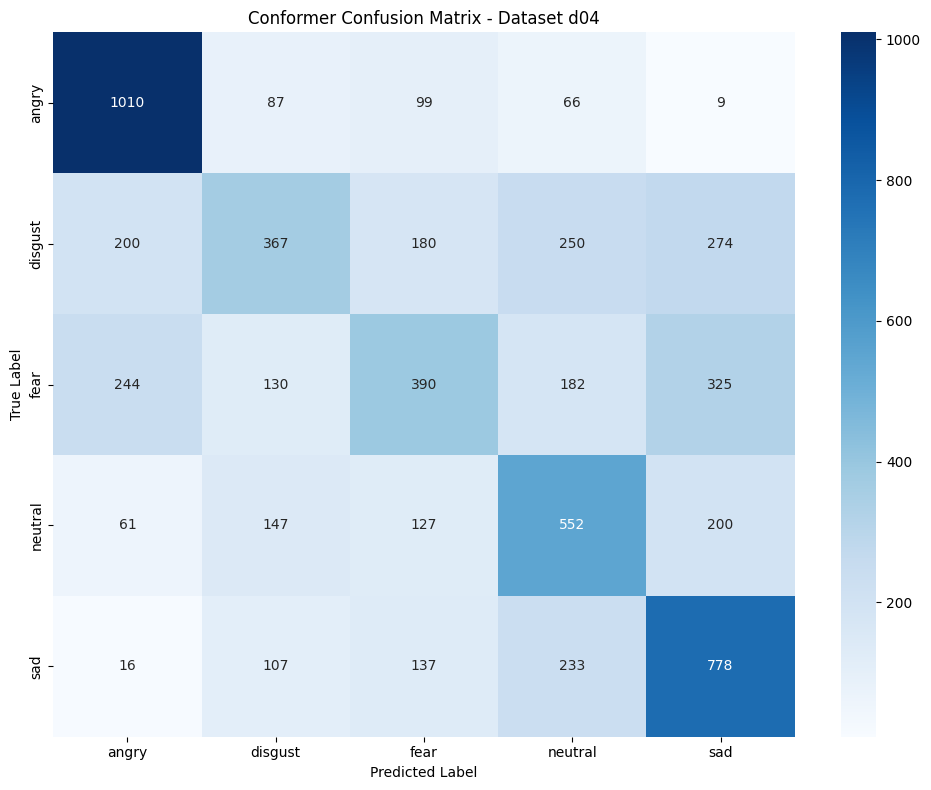

In [8]:
# Confusion Matrix
print(f"\nCONFUSION MATRIX:")
print("-" * 50)
cm = confusion_matrix(y_test, y_pred)

# Print confusion matrix in text format
print("Predicted ->")
print(f"{'True':<8}", end="")
for class_name in class_names:
    print(f"{class_name:<10}", end="")
print()

for i, class_name in enumerate(class_names):
    print(f"{class_name:<8}", end="")
    for j in range(len(class_names)):
        print(f"{cm[i,j]:<10}", end="")
    print()

# Visualize Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Conformer Confusion Matrix - Dataset d04')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

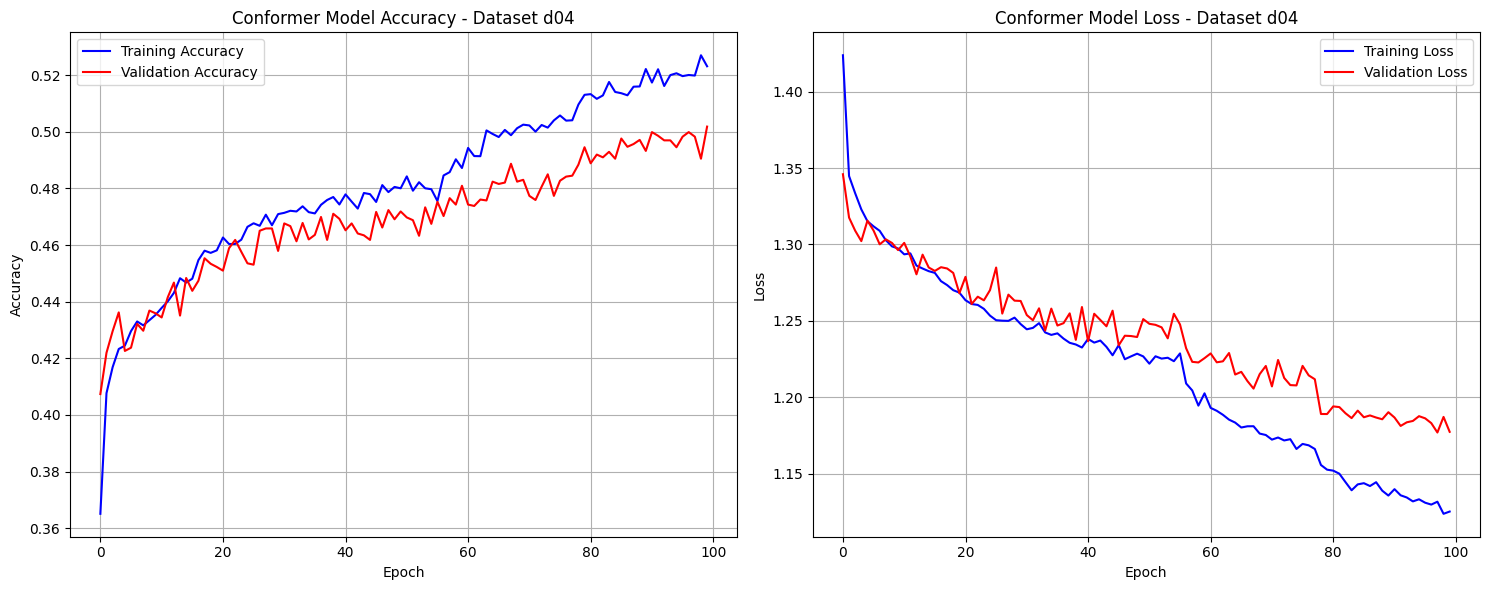

Training history plots generated!


In [9]:
# Plot Training History
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', color='red')
ax1.set_title('Conformer Model Accuracy - Dataset d04')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='red')
ax2.set_title('Conformer Model Loss - Dataset d04')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print("Training history plots generated!")

In [ ]:
# Final summary
print(f"\nFINAL RESULTS SUMMARY - Conformer d04")
print("=" * 60)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Cohen's Kappa: {kappa:.4f}")
print(f"Epochs Trained: {epochs_trained}")
print(f"Dataset: data_features_d04.csv")
print(f"Classes: {', '.join(class_names)}")


FINAL RESULTS SUMMARY - Conformer d04
Test Accuracy: 0.5019
Cohen's Kappa: 0.3775
Epochs Trained: 100
Dataset: data_features_d04.csv
Classes: angry, disgust, fear, neutral, sad


: 